## Imports

In [1]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import csv
import PySimpleGUI as sg
import math
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg, NavigationToolbar2Tk
import numpy as np


In [40]:
df = pd.read_csv("crimeCO-1974-2023.csv")
columns = list(df.columns)
# columns= columns[3:]
# columns
print(columns)
print(df["agency"].nunique())
print(df.shape)

['agency', 'ori', 'year', 'aggravatedAssault', 'allOtherOffensesExceptTraffic', 'arson', 'burglary', 'curfewLoiteringLawViolations', 'disorderlyConduct', 'drivingUnderTheInfluence', 'drugAbuseViolationsGrandTotal', 'drunkenness', 'embezzlement', 'forgeryAndCounterfeiting', 'fraud', 'gamblingTotal', 'humanTraffickingCommercialSexActs', 'humanTraffickingInvoluntaryServitude', 'larcenyTheft', 'liquorLaws', 'manslaughterByNegligence', 'motorVehicleTheft', 'murderAndNonnegligentManslaughter', 'offensesAgainstTheFamilyAndChildren', 'prostitutionAndCommercializedVice', 'rape', 'robbery', 'sexOffensesExceptRapeAndProstitutionAndCommercializedVice', 'simpleAssault', 'stolenPropertyBuyingReceivingPossessing', 'suspicion', 'vagrancy', 'vandalism', 'weaponsCarryingPossessingEtc']
243
(7798, 34)


In [41]:
s = "'agency', 'ori', 'year', 'aggravatedAssault', 'allOtherOffensesExceptTraffic', 'arson', 'burglary', 'curfewLoiteringLawViolations', 'disorderlyConduct', 'drivingUnderTheInfluence', 'drugAbuseViolationsGrandTotal', 'drunkenness', 'embezzlement', 'forgeryAndCounterfeiting', 'fraud', 'gamblingTotal', 'humanTraffickingCommercialSexActs', 'humanTraffickingInvoluntaryServitude', 'larcenyTheft', 'liquorLaws', 'manslaughterByNegligence', 'motorVehicleTheft', 'murderAndNonnegligentManslaughter', 'offensesAgainstTheFamilyAndChildren', 'prostitutionAndCommercializedVice', 'rape', 'robbery', 'sexOffensesExceptRapeAndProstitutionAndCommercializedVice', 'simpleAssault', 'stolenPropertyBuyingReceivingPossessing', 'suspicion', 'vagrancy', 'vandalism', 'weaponsCarryingPossessingEtc'"
s.replace("'","")


'agency, ori, year, aggravatedAssault, allOtherOffensesExceptTraffic, arson, burglary, curfewLoiteringLawViolations, disorderlyConduct, drivingUnderTheInfluence, drugAbuseViolationsGrandTotal, drunkenness, embezzlement, forgeryAndCounterfeiting, fraud, gamblingTotal, humanTraffickingCommercialSexActs, humanTraffickingInvoluntaryServitude, larcenyTheft, liquorLaws, manslaughterByNegligence, motorVehicleTheft, murderAndNonnegligentManslaughter, offensesAgainstTheFamilyAndChildren, prostitutionAndCommercializedVice, rape, robbery, sexOffensesExceptRapeAndProstitutionAndCommercializedVice, simpleAssault, stolenPropertyBuyingReceivingPossessing, suspicion, vagrancy, vandalism, weaponsCarryingPossessingEtc'

In [10]:
df2 = pd.read_csv("crimeCO-2.csv")

## Compare 2 Feeds

In [32]:
data = {}
with open('crimeCO.csv', mode ='r') as file:   
        
       # reading the CSV file
       csvFile = csv.DictReader(file)
 
       # displaying the contents of the CSV file
       for lines in csvFile:
            ori=lines["ori"]
            year=lines["year"]
            if ori in data:
                data[ori][year]=lines
            else:
                data[ori] = {}
                data[ori][year]=lines
            

In [36]:
ngood=0
with open('crimeCO-2.csv', mode ='r') as file:   
        
       # reading the CSV file
       csvFile = csv.DictReader(file)
 
       # displaying the contents of the CSV file
       for lines2 in csvFile:
            ori=lines2["ori"]
            year=lines2["year"]
            if ori not in data or year not in data[ori]:
                print("Missed ori/year ",ori,year)
            else:
                line = data[ori][year]

                for key in lines2.keys():
                   
                    if key not in line:
                        print("Bad Key ",key,ori,year)
                    elif line[key] != lines2[key]:
                        print("BAD ",ori,year,key,line[key],lines2[key])
                    else:
                        ngood+=1
                        
            

In [34]:
ngood

137870

## Gap Assessment

### Percentage Missing

In [3]:
oris = df["ori"].unique().tolist()

In [4]:
cover = []
tyears=[]
for ori in oris:
    a = df.loc[df["ori"] == ori]
    ymin = a["year"].min()
    ymax = a["year"].max()
    if not math.isnan(ymin) and not math.isnan(ymax):
        years = a["year"].unique().tolist()
        nyears = ymax-ymin+1
        if nyears > 0:
            pp = 100 - len(years)/nyears*100
        else:
            pp=100
            
        cover.append(pp)
        tyears.append(a["year"].nunique())
  #      print(ori,ymin,ymax,len(years))
        # for yr in range(ymin,ymax+1):
        #     if yr not in years:
        #         print(ori,yr,ymin,ymax)

21.13204992137493


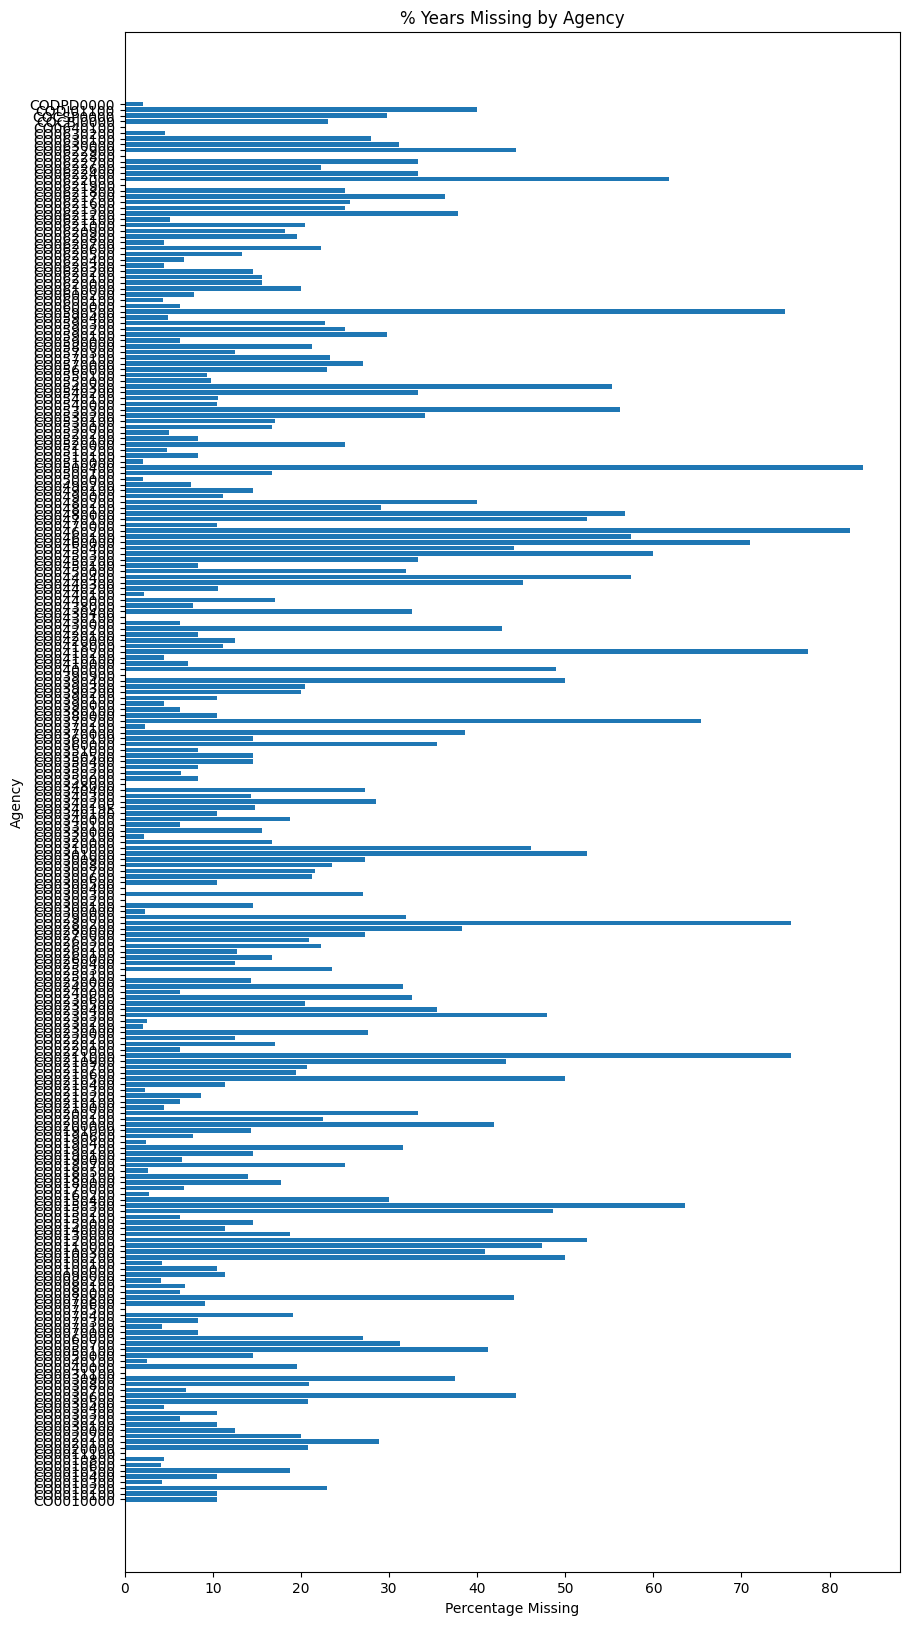

In [13]:
#plt.bar(oris,tyears)
#fig,ax = plt.subplot(size=(10,20))
plt.figure(figsize=(10,20))
plt.barh(oris,cover)
plt.title("% Years Missing by Agency")
plt.xlabel("Percentage Missing")
plt.ylabel("Agency")

print(sum(cover)/len(cover))

In [11]:
len(oris)

243

32.09053497942387


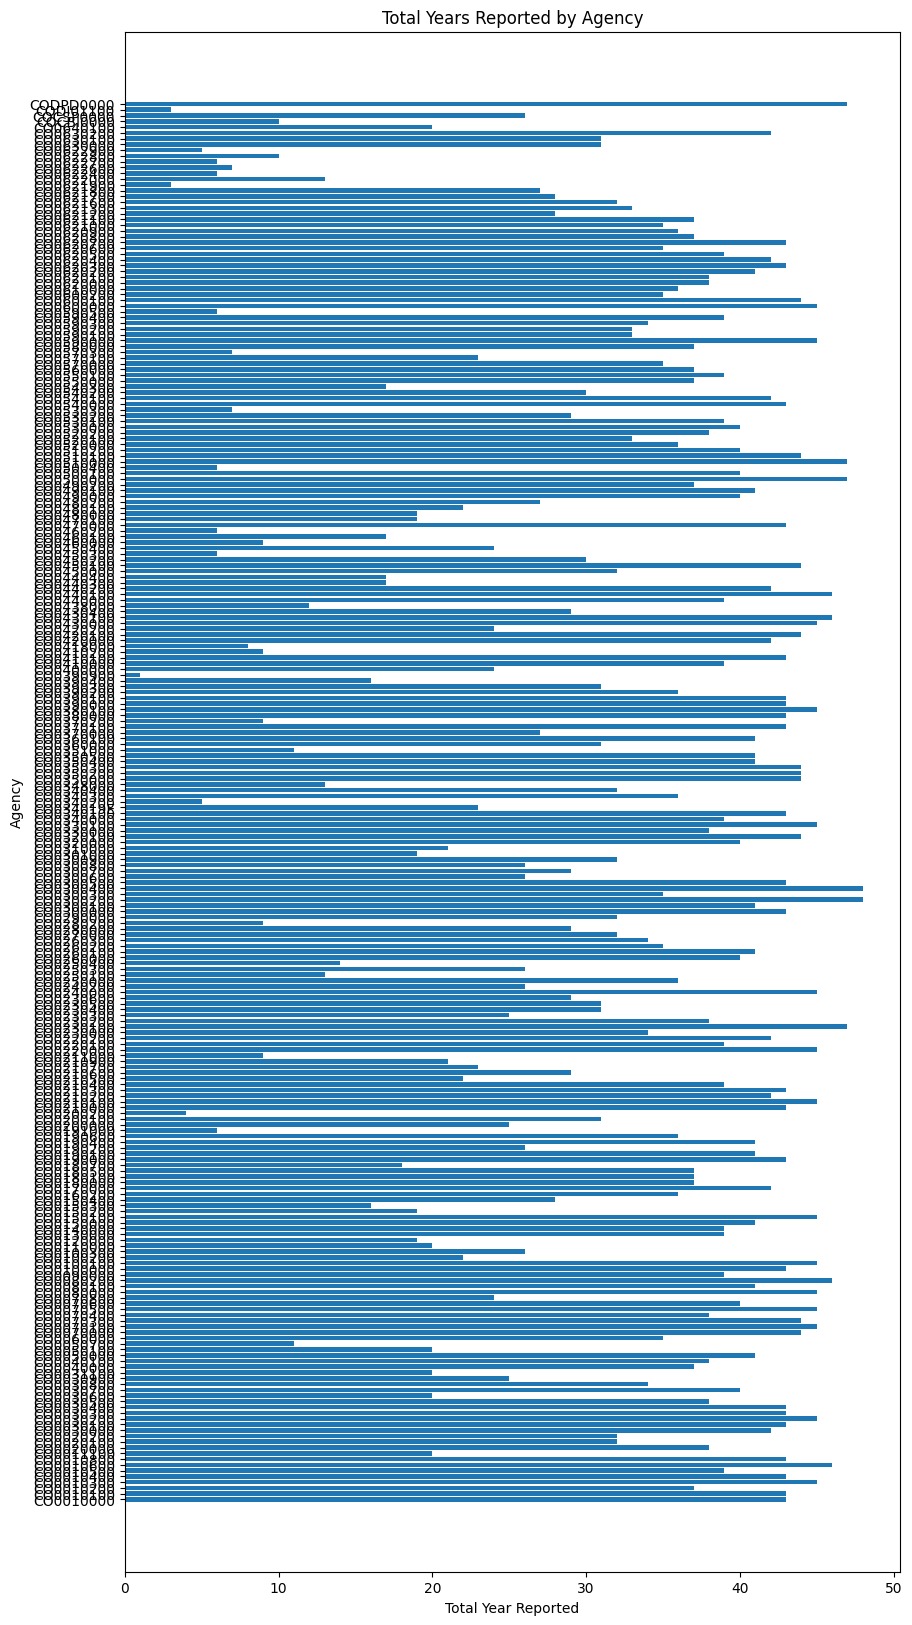

In [14]:
plt.figure(figsize=(10,20))
plt.barh(oris,tyears)
plt.title("Total Years Reported by Agency")
plt.xlabel("Total Year Reported")
plt.ylabel("Agency")

print(sum(tyears)/len(tyears))

In [47]:
ymin = df["year"].min()
ymax = df["year"].max()

print(ymin,ymax)

1974 2021


### Heat Map of Coverage

In [20]:
xlabels = [year for year in range(1974,2022)]
ncols = ymax-ymin+1
nrows = len(oris)
data =np.zeros((nrows,ncols))
data2 =np.zeros((nrows,ncols))

nrow=0
for ori in oris:
   
    a = df.loc[df["ori"] == ori]
    for ii in range(a.shape[0]):
        yr = a.iloc[ii,2]
        ss = a.iloc[ii,3:].sum()
        ncol = yr-ymin
        data[nrow,ncol]=ss               
    nrow+=1     

In [21]:
for nn in range(len(data)):
    mx = max(data[nn])

    for mm in range(len(data[nn])):
        if mx > 0:
          data2[nn][mm] = data[nn][mm]/mx*100
        else:
          data2[nn][mm] = 0

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5,
        22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5, 32.5,
        33.5, 34.5, 35.5, 36.5, 37.5, 38.5, 39.5, 40.5, 41.5, 42.5, 43.5,
        44.5, 45.5, 46.5, 47.5]),
 [Text(0.5, 0, '1974'),
  Text(1.5, 0, '1975'),
  Text(2.5, 0, '1976'),
  Text(3.5, 0, '1977'),
  Text(4.5, 0, '1978'),
  Text(5.5, 0, '1979'),
  Text(6.5, 0, '1980'),
  Text(7.5, 0, '1981'),
  Text(8.5, 0, '1982'),
  Text(9.5, 0, '1983'),
  Text(10.5, 0, '1984'),
  Text(11.5, 0, '1985'),
  Text(12.5, 0, '1986'),
  Text(13.5, 0, '1987'),
  Text(14.5, 0, '1988'),
  Text(15.5, 0, '1989'),
  Text(16.5, 0, '1990'),
  Text(17.5, 0, '1991'),
  Text(18.5, 0, '1992'),
  Text(19.5, 0, '1993'),
  Text(20.5, 0, '1994'),
  Text(21.5, 0, '1995'),
  Text(22.5, 0, '1996'),
  Text(23.5, 0, '1997'),
  Text(24.5, 0, '1998'),
  Text(25.5, 0, '1999'),
  Text(26.5, 0, '2000'),
  Tex

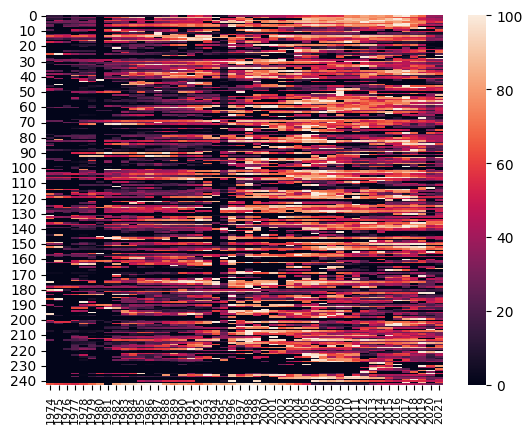

In [30]:
sns.heatmap(data2,xticklabels=xlabels)
plt.xticks(rotation=90, fontsize=8) 

In [28]:
counts=df.groupby("year",as_index=False).count()["Agency"].tolist()
years = sorted(df["year"].unique().tolist())

Text(0.5, 1.0, '# of Police Departments')

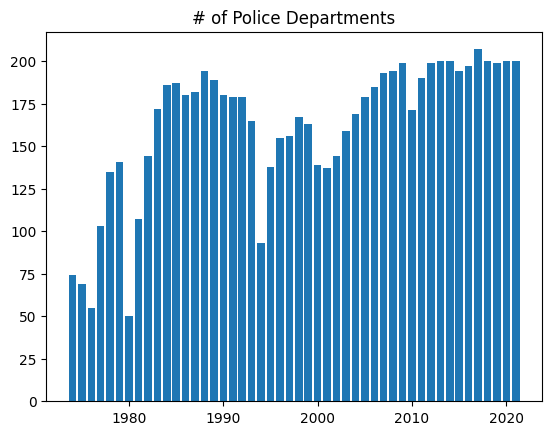

In [31]:
plt.bar(years,counts)
plt.title("# of Police Departments")

In [ ]:
columns = list(df.columns)
columns= columns[3:]
columns

In [ ]:
len(columns)

In [ ]:
figure, axis = plt.subplots(11, 3,sharex=True,squeeze=False,figsize=(8,17))
nplot=0
figure.tight_layout(pad=5.0)
for nrow in range(0,12):
    for ncol in range(0,3):
        if nplot < len(columns):
            col=columns[nplot]
            axis[nrow, ncol].bar(a["year"], a[col])
            axis[nrow,ncol].set_title(col)
            nplot+=1

In [ ]:
import plotly.graph_objects as go
from ipywidgets import widgets

In [ ]:
cols = widgets.Dropdown(
    options=columns,
    description='Incidents:',
)

In [6]:
ad = pd.read_json("CO0010000.json")
ad.head()

,data_year,state_id,state_abbr,ori,population,active,published,covered,nibrs_submitting,nibrs_start_date,leoka_submitting,leoka_start_date,pe_reported_flag,srs_submitting,hc_submitting,asr_submitting,supp_submitting
0,2014,7,CO,CO0010000,98569,True,True,False,True,1997-01-01T00:00:00.000Z,True,2003-03-01T00:00:00.000Z,True,True,True,True,True
1,2001,7,CO,CO0010000,82523,True,True,False,True,1997-01-01T00:00:00.000Z,False,2003-03-01T00:00:00.000Z,True,True,True,True,True
2,2013,7,CO,CO0010000,97146,True,True,False,True,1997-01-01T00:00:00.000Z,True,2003-03-01T00:00:00.000Z,True,True,True,True,True
3,1989,7,CO,CO0010000,77132,True,True,False,False,1997-01-01T00:00:00.000Z,False,2003-03-01T00:00:00.000Z,True,True,False,True,True
4,2000,7,CO,CO0010000,80349,True,True,False,True,1997-01-01T00:00:00.000Z,False,2003-03-01T00:00:00.000Z,True,True,True,True,True


In [9]:
ymin = ad["data_year"].min()
ymax = ad["data_year"].max()

In [11]:
years = ad["data_year"].unique().tolist()

for yr in range(ymin,ymax+1):
    if yr not in years:
        print("Miss ",yr)

In [12]:
a = df.loc[df["ori"] == "CO0010000"]

In [16]:
yearsd = a["year"].unique().tolist()

In [17]:
for yr in range(ymin,ymax+1):
    if yr not in yearsd:
        print("Miss ",yr)

Miss  1960
Miss  1961
Miss  1962
Miss  1963
Miss  1964
Miss  1965
Miss  1966
Miss  1967
Miss  1968
Miss  1969
Miss  1970
Miss  1971
Miss  1972
Miss  1973
Miss  1976
Miss  1978
Miss  1979
Miss  1990
Miss  1994
Miss  2022


In [27]:
hld=df.loc[df["Agency"].str.contains("Adam")]

In [28]:
for index,row in hld.iterrows():
    print(row["ori"],row["year"],row["Agency"])

CO0010000 1974 Adams County Sheriff's Office
CO0010000 1975 Adams County Sheriff's Office
CO0010000 1977 Adams County Sheriff's Office
CO0010000 1980 Adams County Sheriff's Office
CO0010000 1981 Adams County Sheriff's Office
CO0010000 1982 Adams County Sheriff's Office
CO0010000 1983 Adams County Sheriff's Office
CO0010000 1984 Adams County Sheriff's Office
CO0010000 1985 Adams County Sheriff's Office
CO0010000 1986 Adams County Sheriff's Office
CO0010000 1987 Adams County Sheriff's Office
CO0010000 1988 Adams County Sheriff's Office
CO0010000 1989 Adams County Sheriff's Office
CO0010000 1991 Adams County Sheriff's Office
CO0010000 1992 Adams County Sheriff's Office
CO0010000 1993 Adams County Sheriff's Office
CO0010000 1995 Adams County Sheriff's Office
CO0010000 1996 Adams County Sheriff's Office
CO0010000 1997 Adams County Sheriff's Office
CO0010000 1998 Adams County Sheriff's Office
CO0010000 1999 Adams County Sheriff's Office
CO0010000 2000 Adams County Sheriff's Office
CO0010000 

In [18]:
cim = pd.read_csv("https://data.colorado.gov/api/views/2e5i-5hfy/rows.csv?accessType=DOWNLOAD")

In [22]:
cim["policeDistrict"].value_counts()

policeDistrict
Pueblo PD                     486
Montezuma County Sheriff      486
Summit County Sheriff         459
Burlington PD                 432
La Junta PD                   432
                             ... 
Collbran PD                     2
La Veta Marshal                 2
Univ. Southern Colorado PD      2
Sanford PD                      2
Summit County Task Force        1
Name: count, Length: 284, dtype: int64

In [21]:
cim.groupby(["policeDistrict","year"],as_index=False).sum()

,policeDistrict,year,adultCount,juvenileCount,type
0,22nd Judical District Task Force,2007,0.0,1.0,EmbezzlementDisorderly ConductAggravated Assau...
1,22nd Judical District Task Force,2008,41.0,3.0,ForgeryMurder Non Negligent ManslaughterLarcen...
2,22nd Judical District Task Force,2009,8.0,0.0,Other Sex OffensesLarcenyCurfew ViolationsAggr...
3,22nd Judical District Task Force,2010,0.0,0.0,Disorderly ConductForgeryDrug ViolationsOther ...
4,22nd Judical District Task Force,2011,14.0,0.0,VagrancyForcible RapeOther Family OffensesLarc...
...,...,...,...,...,...
3872,Yuma PD,2012,179.0,18.0,Motor Vehicle TheftForgeryMurder Non Negligent...
3873,Yuma PD,2013,72.0,15.0,ProstitutionDUIStolen PropertyOther Sex Offens...
3874,Yuma PD,2014,46.0,7.0,WeaponsGamblingVandalismDrug ViolationsAggrava...
3875,Yuma PD,2015,71.0,1.0,Murder Non Negligent ManslaughterRapeRobberyAg...


## Agencies

In [30]:
agencies = pd.read_json("agencies-cde.json")

In [31]:
#agencies.head()
for index,row in agencies.iterrows():
    print(row["ori"],row["nibrs_start_date"],row["agency_name"])

CO0010000 1997-01-01T00:00:00.000Z Adams County Sheriff's Office
CO0010100 1985-01-01T00:00:00.000Z Aurora Police Department
CO0010200 2004-09-01T00:00:00.000Z Brighton Police Department
CO0010300 1997-01-01T00:00:00.000Z Commerce City Police Department
CO0010400 2012-01-01T00:00:00.000Z Thornton Police Department
CO0010500 1997-01-01T00:00:00.000Z Westminster Police Department
CO0010600 1997-01-01T00:00:00.000Z Northglenn Police Department
CO0010800 1997-01-01T00:00:00.000Z Federal Heights Police Department
CO0011100 2002-01-01T00:00:00.000Z University of Colorado: Denver
CO0020000 1997-01-01T00:00:00.000Z Alamosa County Sheriff's Office
CO0020100 2012-01-01T00:00:00.000Z Alamosa Police Department
CO0020200 1997-07-01T00:00:00.000Z Adams State University
CO0030000 1997-01-01T00:00:00.000Z Arapahoe County Sheriff's Office
CO0030100 1992-01-01T00:00:00.000Z Englewood Police Department
CO0030200 2011-01-01T00:00:00.000Z Littleton Police Department
CO0030300 1997-01-01T00:00:00.000Z Sheri

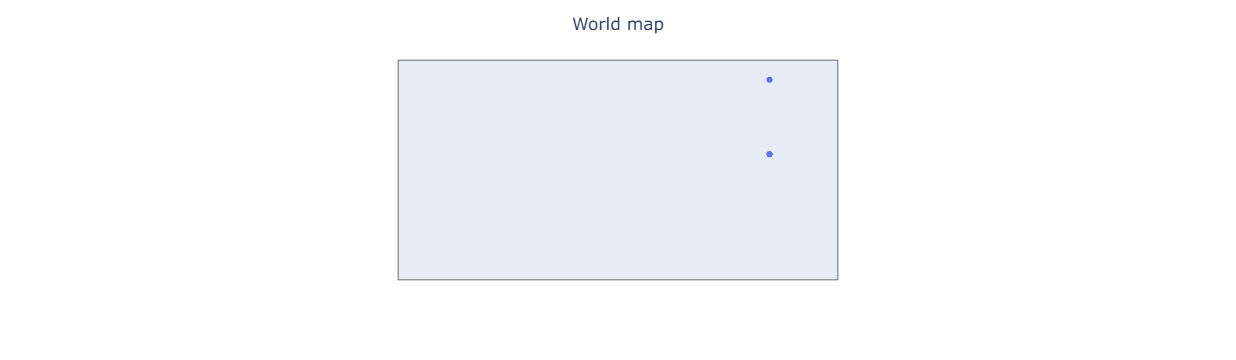

In [73]:
fig = px.scatter_geo(agencies, lat='latitude', lon='longitude', hover_name="agency_name",locationmode="USA-states")
fig.update_layout(title = 'World map', title_x=0.5)
fig.show()

## GUI

In [ ]:

# グラフツールバーを呼び出すクラス
class Toolbar(NavigationToolbar2Tk):
    def __init__(self, *args, **kwargs):
        super(Toolbar, self).__init__(*args, **kwargs)


# figureを作成する関数
def draw_plot(col,dept,ori):
    if dept == "State":
        a = df.groupby("year",as_index=False).sum()
    else:
        a = df.loc[df["ori"] == ori]
        
    fig = plt.figure()
    ax = fig.add_subplot()
    x = a["year"]
    y = a[col]
    ax.bar(x, y)
    ax.set_xlabel('Yecar')
    ax.set_ylabel('Count')
    ax.set_title(f"{col} for {dept} ({ori})")

    return fig


def draw_plot2(ori,dept="State"):
    print("ORI ",ori," Dept ",dept)
    if ori != "State":
        a = df.loc[df["ori"] == ori]
        ymin = a["year"].min()
        ymax = a["year"].max()
        print("MN,MX ",ymin,ymax)
        totals = [0]*int(ymax-ymin+1)
        a.iloc[1,3:].sum()
        a.iloc[1,2]
        nrows=a.shape[0]
        years = [year for year in range(ymin,ymax+1)]
        for nn in range(nrows):
            year=a.iloc[nn,2]
            ss = a.iloc[nn,3:].sum()
            ni = year-ymin
            totals[ni]=ss
                 
        
        fig = plt.figure()
        ax = fig.add_subplot()
        x = years
        y = totals
        ax.bar(years, totals)
        ax.set_xlabel('Year')
        ax.set_ylabel('Count')
        ax.set_title(f"All Crimes for {dept} ({ori})")

    return fig

def draw_figure_w_toolbar(canvas, fig, canvas_toolbar):
    # 更新処理がされた時に一旦グラフを消去する
    if canvas.children:
        for child in canvas.winfo_children():
            child.destroy()
    # 一旦ツールバーを消去する
    if canvas_toolbar.children:
        for child in canvas_toolbar.winfo_children():
            child.destroy()
    # ここで実際にgui上に書きこむ処理をする
    figure_canvas_agg = FigureCanvasTkAgg(fig, master=canvas)
    figure_canvas_agg.draw()
    toolbar = Toolbar(figure_canvas_agg, canvas_toolbar)
    toolbar.update()
    figure_canvas_agg.get_tk_widget().pack(side='left', fill='both', expand=2)
    
                        
departments = ["State:State"]
oris=["State"]
#departments[1:] = list(df["Agency"].unique())
oris[1:] = list(df["ori"].unique())

for ori in oris:
   a = df.loc[df["ori"] == ori,"Agency"].tolist()
   if len(a) > 0:
        departments.append(f"{a[0]}:{ori}")                        
                        
                        
                        

# gui上のツールバーを描画するcanvasを定義
figure_canvas_control = [sg.Canvas(key='controls_cv')]

# gui上のfigureを描画するcanvasを定義
figure_canvas = [sg.Canvas(key='fig_cv',
                           # ! サイズを確保しておく。
                           size=(400 * 2, 400))]

# レイアウトを定義
layout = [
    [sg.Button('PLOT'), sg.Cancel(), sg.Button('Total')],
    [sg.T("Incident Type"),sg.Combo(values=columns,key="-CRIME-",enable_events=True)],
    [sg.T("Police Department"),sg.Combo(values=departments,key="-DEPTS-",enable_events=True)],
    [sg.T('Controls:')],
    figure_canvas_control,
    [sg.T('Figure:')],
    figure_canvas
]

# windowを作成
window = sg.Window('matplotlib graph', layout)

while True:
    try: 
        event, values = window.read()
        print(event,values)
        if event in (sg.WIN_CLOSED, 'Cancel'):
            break
        elif event == 'Plot':
            # windowに書きこむfigureを作成して受け取り
            drawing_fig = draw_plot()
            # windowに当てはめる処理をする
            draw_figure_w_toolbar(window['fig_cv'].TKCanvas,
                                  drawing_fig,
                                  window['controls_cv'].TKCanvas)
        elif event == 'PLOT':
            col=values["-CRIME-"]
            dept = values["-DEPTS-"]
            dd = dept.split(":")
            dept = dd[0]
            ori = dd[1]
            
            if len(col) > 3: 
                drawing_fig = draw_plot(col,dept,ori)
                # windowに当てはめる処理をする
                draw_figure_w_toolbar(window['fig_cv'].TKCanvas,
                                      drawing_fig,
                                      window['controls_cv'].TKCanvas)
            else:
                sg.Popup("Please Choose an Incedent Type to Plot")
        elif event == 'Total':
            depts = values["-DEPTS-"]
            dd = depts.split(":")
            dept=dd[0]
            ori = dd[1]
            print("SEL ",ori,depts)
            drawing_fig = draw_plot2(ori,dept)
            # windowに当てはめる処理をする
            draw_figure_w_toolbar(window['fig_cv'].TKCanvas,
                                  drawing_fig,
                                  window['controls_cv'].TKCanvas)
    except Exception as err:
        print("Error: ",err)

window.close()

-DEPTS- {'-CRIME-': '', '-DEPTS-': "Adams County Sheriff's Office:CO0010000", 'controls_cv': None, 'fig_cv': None}
Total {'-CRIME-': '', '-DEPTS-': "Adams County Sheriff's Office:CO0010000", 'controls_cv': None, 'fig_cv': None}
SEL  CO0010000 Adams County Sheriff's Office:CO0010000
ORI  CO0010000  Dept  Adams County Sheriff's Office
MN,MX  1974 2021
-DEPTS- {'-CRIME-': '', '-DEPTS-': 'Northglenn Police Department:CO0010600', 'controls_cv': None, 'fig_cv': None}
Total {'-CRIME-': '', '-DEPTS-': 'Northglenn Police Department:CO0010600', 'controls_cv': None, 'fig_cv': None}
SEL  CO0010600 Northglenn Police Department:CO0010600
ORI  CO0010600  Dept  Northglenn Police Department
MN,MX  1974 2021
-DEPTS- {'-CRIME-': '', '-DEPTS-': 'Aurora Police Department:CO0010100', 'controls_cv': None, 'fig_cv': None}
-DEPTS- {'-CRIME-': '', '-DEPTS-': 'Dinosaur Police Department:CO0410200', 'controls_cv': None, 'fig_cv': None}
Total {'-CRIME-': '', '-DEPTS-': 'Dinosaur Police Department:CO0410200', 'cont

In [ ]:
df.head()

In [ ]:
ymin,ymax

In [ ]:

df.iloc[1,3:].sum()

In [ ]:
data[1]

In [ ]:
ori = "CO0010000"

a = df.loc[df["ori"] == ori]
ymin = a["year"].min()
ymax = a["year"].max()
totals = [0]*(ymax-ymin+1)
a.iloc[1,3:].sum()
a.iloc[1,2]
nrows=a.shape[0]
years = [year for year in range(ymin,ymax+1)]
for nn in range(nrows):
    print(nn)
    year=a.iloc[nn,2]
    ss = a.iloc[nn,3:].sum()
    ni = year-ymin
    totals[ni]=ss
    print(year,ymin,ymax,ni,ss)

print(len(totals),len(years))

In [ ]:
plt.bar(years,totals)

In [ ]:
totals